In [202]:
import pandas as pd

fish=pd.read_csv('./data/fish.csv')
fish



,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672


In [203]:
#어떤 종류의 생선이 있는지 
pd.unique(fish['Species'])


<StringArray>
['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt']
Length: 7, dtype: str

Bream      → 도미
Roach      → 송어
Whitefish  → 송어
Parkki     → 돔
Perch      → 농어
Pike       → 꼬치고기
Smelt      → 빙어

In [204]:
#특성과 타겟분리. 2차 배열로 만들기
#종열을 타겟으로 만들고 나머지 5개의 열은 입력 데이터로 사용하자
fish_input=fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()
fish_input[:5]

array([[242.    ,  25.4   ,  30.    ,  11.52  ,   4.02  ],
       [290.    ,  26.3   ,  31.2   ,  12.48  ,   4.3056],
       [340.    ,  26.5   ,  31.1   ,  12.3778,   4.6961],
       [363.    ,  29.    ,  33.5   ,  12.73  ,   4.4555],
       [430.    ,  29.    ,  34.    ,  12.444 ,   5.134 ]])

In [205]:
fish_input.shape,fish.shape

((159, 5), (159, 6))

In [206]:
#타겟데이터 만들기
fish_target=fish[['Species']].to_numpy()
fish_target[:5]

array([['Bream'],
       ['Bream'],
       ['Bream'],
       ['Bream'],
       ['Bream']], dtype=object)

In [207]:
fish_target.shape

(159, 1)

In [208]:
#훈련과 테스트 분리
from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input, fish_target, random_state=42)

In [209]:
train_input.shape,test_input.shape,train_target.shape,test_target.shape

((119, 5), (40, 5), (119, 1), (40, 1))

In [105]:
#표준화 중요, 평균 ,표준편차 통계값 계산
from sklearn.preprocessing import StandardScaler
ss=StandardScaler() #표준화 해주는 함수 가져와
ss.fit(train_input) #학습(평균과 표준편차 학습)
#그 통계값을 이용해 데이터를 변환 하는 단계(스케일링)
train_scaled=ss.transform(train_input) #실제변환
test_scaled=ss.transform(test_input)


# 2️⃣ k-최근접 이웃 분류기의 확률 예측

In [210]:
from sklearn.neighbors import KNeighborsClassifier
kn=KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled,train_target)

c:\Users\06pc-00\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [108]:
kn.score(train_scaled,train_target)

0.8907563025210085

In [112]:
kn.score(test_scaled,test_target)

0.85

In [212]:
# #타겟값 전달한것 확인
# pd.unique(fish_target)

개념	의미
feature	입력 데이터
target	맞춰야 하는 값
class	target의 종류

In [114]:
#모델이 학습한 값은_붙음, 모델이 학습하면서 인식한 클래스(종류) 목록, 타겟안에 있는 정답 종류
kn.classes_

array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype=object)

In [115]:
#테스트세트에 있는 처음 5개의 타깃값을 예측해 보자
kn.predict(test_scaled[:5])

array(['Perch', 'Smelt', 'Pike', 'Perch', 'Perch'], dtype=object)

In [116]:
#5개 셈플에 대한 예측은 어떤확률로 만들어 졌을까?
#사이킷런의 분류 모델은 predict_proba()메서드로 클래스별 확률값을 반환한다.
import numpy as np
proba=kn.predict_proba(test_scaled[:5])
np.round(proba, decimals=4)


array([[0.    , 0.    , 1.    , 0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    , 1.    , 0.    ],
       [0.    , 0.    , 0.    , 1.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.6667, 0.    , 0.3333, 0.    , 0.    ],
       [0.    , 0.    , 0.6667, 0.    , 0.3333, 0.    , 0.    ]])

In [117]:
#네번째 셈플의 최근접 이웃을 확인해 보자
distance,indexes=kn.kneighbors(test_scaled[3:4])
train_target[indexes]

#퍼치 확률 2/3, 로치 확률 1/3

array([[['Roach'],
        ['Perch'],
        ['Perch']]], dtype=object)

In [ ]:
#확률이기에는 너무 단순, 다른방법 찾아보자

# 로지스틱 회기

In [ ]:
#시그모이드 함수: z= a*무게+b*길이 ...+ f 
# a,b,c,d,e는 가중치 혹은 계수
#f 는 절편

#z의 값은 어떤값도 가능, 하지만 확률이 되려면 0~1사이의 값이 되어야 한다.
#z가 아주 큰 음수일때 0 이 되고, z가 아주 큰 양수일때 1이 되도록 바꾸어줌-> 시그모이드함수
#시그모이드 값이 0.5를 기준을 양성, 음성

#z는 x축(입력값)
#시그모이드(z)는 y축(확률)

In [118]:
z=np.arange(-5,5,0.1)
z

array([-5.00000000e+00, -4.90000000e+00, -4.80000000e+00, -4.70000000e+00,
       -4.60000000e+00, -4.50000000e+00, -4.40000000e+00, -4.30000000e+00,
       -4.20000000e+00, -4.10000000e+00, -4.00000000e+00, -3.90000000e+00,
       -3.80000000e+00, -3.70000000e+00, -3.60000000e+00, -3.50000000e+00,
       -3.40000000e+00, -3.30000000e+00, -3.20000000e+00, -3.10000000e+00,
       -3.00000000e+00, -2.90000000e+00, -2.80000000e+00, -2.70000000e+00,
       -2.60000000e+00, -2.50000000e+00, -2.40000000e+00, -2.30000000e+00,
       -2.20000000e+00, -2.10000000e+00, -2.00000000e+00, -1.90000000e+00,
       -1.80000000e+00, -1.70000000e+00, -1.60000000e+00, -1.50000000e+00,
       -1.40000000e+00, -1.30000000e+00, -1.20000000e+00, -1.10000000e+00,
       -1.00000000e+00, -9.00000000e-01, -8.00000000e-01, -7.00000000e-01,
       -6.00000000e-01, -5.00000000e-01, -4.00000000e-01, -3.00000000e-01,
       -2.00000000e-01, -1.00000000e-01, -1.77635684e-14,  1.00000000e-01,
        2.00000000e-01,  

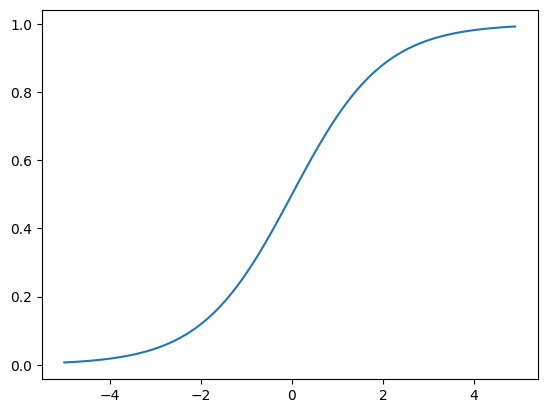

In [119]:
import numpy as np
import matplotlib.pyplot as plt
z=np.arange(-5,5,0.1)
phi=1/(1+np.exp(-z))
plt.plot(z,phi)

# 4️⃣ 로지스틱 회귀로 이진 분류 수행하기

In [ ]:
#훈련하기전 간단한 이진분류 해보기
#시그모이드 함수의 출려기 0.5 보다 크면 양성, 0.5보다 작은면 음성으로 판단
#도미와 방어 2개를 사용한다.



In [201]:
bream_smelt_indexes=(train_target=='Bream') | (train_target=='Smelt')

train_bream_smelt = train_scaled[bream_smelt_indexes]
train_bream_smelt
target_bream_smelt = train_target[bream_smelt_indexes]
target_bream_smelt

IndexError: boolean index did not match indexed array along axis 1; size of axis is 5 but size of corresponding boolean axis is 1

In [84]:
# train_target을 1차원으로 변환
train_target = train_target.reshape(-1)

# Bream 또는 Smelt 위치 찾기
bream_smelt_indexes = (train_target == 'Bream') | (train_target == 'Smelt')

# 입력 데이터 선택
train_bream_smelt = train_scaled[bream_smelt_indexes]

# 타겟 데이터 선택
target_bream_smelt = train_target[bream_smelt_indexes]

print(train_bream_smelt)
print(target_bream_smelt)

[[ 0.91965782  0.60943175  0.81041221  1.85194896  1.00075672]
 [-1.0858536  -1.68646987 -1.70848587 -1.70159849 -2.0044758 ]
 [ 0.63818253  0.56257661  0.73223951  1.64473401  0.50705737]
 [ 0.30041219  0.23459067  0.42823457  1.36042157  0.22329758]
 [ 0.9027693   0.70314202  0.88858491  1.89027545  0.85537174]
 [-1.0824759  -1.61150165 -1.62162731 -1.7000674  -1.92815631]
 [ 0.10337949  0.04717013  0.23714575  0.88445197  0.41799764]
 [ 1.49668216  1.03112796  1.21864741  2.44274986  1.40289707]
 [ 0.23004337  0.23459067  0.42823457  1.3336029   0.39983213]
 [-0.42579405 -0.29018684 -0.11028847  0.65627104 -0.26107519]
 [ 1.28557569  0.70314202  0.89727076  1.98228866  1.06683526]
 [ 0.93373158  0.60943175  0.83646978  1.85150445  0.97832415]
 [ 0.80706771  0.60943175  0.81041221  1.63137406  1.0255057 ]
 [-1.07262426 -1.52716241 -1.55214047 -1.67235972 -1.86207776]
 [ 1.6374198   1.17169337  1.27076255  2.41341232  1.40143407]
 [-1.07966115 -1.63961473 -1.67374245 -1.6462819  -1.87

In [87]:
train_bream_smelt[0,]

array([0.91965782, 0.60943175, 0.81041221, 1.85194896, 1.00075672])

# 모델학습

In [88]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(train_bream_smelt,target_bream_smelt)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [90]:
#훈련한 모델을 사용해 train_bream_smelt에 있는 처음 5개의 셈플을 예측해보자
lr.predict(train_bream_smelt[:5])

array(['Bream', 'Smelt', 'Bream', 'Bream', 'Bream'], dtype=object)

In [92]:
lr.predict_proba(train_bream_smelt[:5])

array([[0.99760007, 0.00239993],
       [0.02737325, 0.97262675],
       [0.99486386, 0.00513614],
       [0.98585047, 0.01414953],
       [0.99767419, 0.00232581]])

In [ ]:
#첫번째 열이 음성클래스(0)애 대한 확률이고 두번째 열이 양성클래스(1)에 대한 확률이다.

In [93]:
lr.classes_

array(['Bream', 'Smelt'], dtype=object)

In [125]:
#로지스틱 회귀가 학습한 계수(coef), 절편(intercept)를 확인해 보자
lr.coef_,lr.intercept_

(array([[-0.40451732, -0.57582787, -0.66248158, -1.01329614, -0.73123131]]),
 array([-2.16172774]))

In [126]:
train_bream_smelt[0,]

array([0.91965782, 0.60943175, 0.81041221, 1.85194896, 1.00075672])

In [131]:
z= (-0.40451732*0.91965782) + (-0.57582787*0.60943175) + (-0.66248158*0.81041221) + (-1.01329614*1.85194896) + (-0.731231310*1.00075672) +(-2.16172774)
z

-6.029913584510324

# decision_function()
- z값 반환
- 이값을 시그모이드에 넣으면 확률

In [136]:
decisions=lr.decision_function(train_bream_smelt[:5])
decisions 

array([-6.02991358,  3.57043428, -5.26630496, -4.24382314, -6.06135688])

In [ ]:
#양수일수록-> 양성클래스일 가능성이 높음
#음수일수록->음성클래스일 가능성이 높음
#절댓값이 클수록 -> 모델이 자신 있게 판단했다는 뜻

In [ ]:
from scipy.special import expit #시그모이드 함수 파이선에서 제공해주는것. 확률값을 알려줌. 
expit(decisions)


array([0.00239993, 0.97262675, 0.00513614, 0.01414953, 0.00232581])

In [138]:
lr.predict_proba(train_bream_smelt[:5])

array([[0.99760007, 0.00239993],
       [0.02737325, 0.97262675],
       [0.99486386, 0.00513614],
       [0.98585047, 0.01414953],
       [0.99767419, 0.00232581]])

# 5️⃣ 로지스틱 회귀로 다중 분류 수행하기


In [191]:
# max_iter는 반복횟수, 기본값은 100
#릿지회귀는 alpha값으로 규제함, 로지스틱회는 C로 규제함, 기본값은 1임, 값이 작을 수록 규제가 커진다.
#C=20으로 규제를 완화함, C는 규제를 조절하는 하이퍼파라미터
lr=LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled,train_target)

c:\Users\06pc-00\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",20
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

In [187]:
lr.score(train_scaled,train_target)

0.9327731092436975

In [188]:
lr.score(test_scaled,test_target)

0.925

In [189]:
lr.predict(test_scaled[:5])

array(['Perch', 'Smelt', 'Pike', 'Roach', 'Perch'], dtype=object)

In [190]:
proba=lr.predict_proba(test_scaled[:5])
np.round(proba, decimals=2)

array([[0.  , 0.01, 0.84, 0.  , 0.13, 0.01, 0.  ],
       [0.  , 0.  , 0.04, 0.  , 0.01, 0.95, 0.  ],
       [0.  , 0.  , 0.03, 0.93, 0.02, 0.02, 0.  ],
       [0.01, 0.03, 0.31, 0.01, 0.57, 0.  , 0.08],
       [0.  , 0.  , 0.9 , 0.  , 0.09, 0.  , 0.  ]])

In [184]:
#1행의 3번째 0.842, 이 생선은 perch농어 일까? classes_속성을 확인해보자
lr.classes_

array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype=object)

In [185]:
# coef_구조
#계수는 7개의 클래스, 
lr.coef_.shape, lr.intercept_.shape

((7, 5), (7,))

In [192]:
# 확률계산은 어떻게 할까? 이진분류에서는 시그모이드함수를 사용해 z를 0과1사이의 값으로 변환함
#다중분류에서는 소프트맥스(softMax)함수를 사용하여 7개의 z 값을 확률로 변환한다. 
# 테스트세트의 처음 5개 셈플에 대한 z1~ z7의 값을 구해보자
decisions= lr.decision_function(test_scaled[:5])
np.round(decisions,decimals=2)

array([[ -6.51,   1.04,   5.17,  -2.76,   3.34,   0.35,  -0.63],
       [-10.88,   1.94,   4.78,  -2.42,   2.99,   7.84,  -4.25],
       [ -4.34,  -6.24,   3.17,   6.48,   2.36,   2.43,  -3.87],
       [ -0.69,   0.45,   2.64,  -1.21,   3.26,  -5.7 ,   1.26],
       [ -6.4 ,  -1.99,   5.82,  -0.13,   3.5 ,  -0.09,  -0.7 ]])

In [193]:
from scipy.special import softmax
proba=softmax(decisions,axis=1)
np.round(proba, decimals=2)

array([[0.  , 0.01, 0.84, 0.  , 0.13, 0.01, 0.  ],
       [0.  , 0.  , 0.04, 0.  , 0.01, 0.95, 0.  ],
       [0.  , 0.  , 0.03, 0.93, 0.02, 0.02, 0.  ],
       [0.01, 0.03, 0.31, 0.01, 0.57, 0.  , 0.08],
       [0.  , 0.  , 0.9 , 0.  , 0.09, 0.  , 0.  ]])

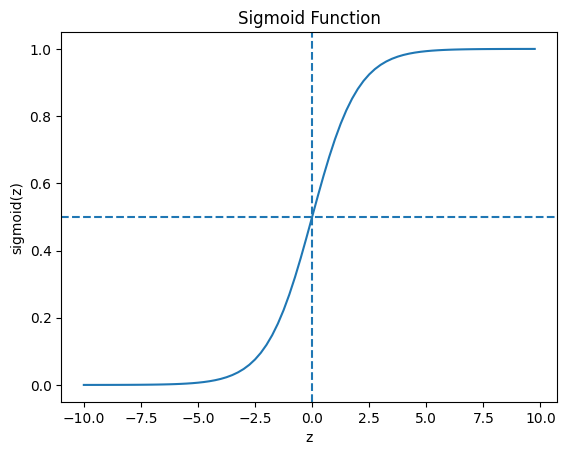

In [214]:
### 문제 1

# 시그모이드 함수 그래프를 직접 그려보시오.
import numpy as np
import matplotlib.pyplot as plt
z=np.arange(-10,10,0.25)
# np.linespace(-10,10,200)

phi=1/(1+np.exp(-z))
plt.plot(z,phi)
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.title('Sigmoid Function')
plt.axhline(0.5, linestyle='--')
plt.axvline(0,linestyle='--')


In [ ]:
### 문제 2

# C 값을 0.1, 1, 10 으로 바꿔 정확도를 비교하시오.

In [ ]:
### 문제 3

# coef_ 값을 보고 어떤 특성이 가장 중요한지 설명하시오.